# Statistical Arbitrage in US Equities
Implementation of Avellaneda & Lee (2010), *Quantitative Finance*, 10:7, 761-782

## Overview
Mean-reversion strategy that decomposes stock returns into systematic and idiosyncratic components. Idiosyncratic residuals are modeled as Ornstein-Uhlenbeck processes. Stocks whose residuals deviate significantly from equilibrium are traded as contrarian bets, expecting reversion.

## Pipeline
1. **PCA Factor Extraction** — Estimate correlation matrix on trailing 252 days, extract eigenportfolios as risk factors (Section 2.1)
2. **Factor Regression** — Regress each stock's returns on factor returns over trailing 60 days, extract idiosyncratic residuals (eq. 10)
3. **OU Estimation** — Cumulate residuals, fit AR(1) to estimate mean-reversion speed, equilibrium level, and equilibrium volatility (Appendix A)
4. **S-score** — Normalize distance from equilibrium, centre cross-sectionally to remove estimation bias (eq. 15, 18, A2)
5. **Position Management** — Open when |s| > 1.25, close when |s| < 0.50–0.75, bang-bang sizing with 2+2 leverage (eq. 16, Section 5)
6. **PNL** — Daily mark-to-market on real returns, 5 bps slippage per side

## 1. Setup
Import modules and load pre-cleaned data (returns, volume, metadata).

In [14]:
%load_ext autoreload
%autoreload 2

import sys
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

from src.data import load_data
from src.factors import run_pca
from src.backtest import run_backtest
from src.diagnostics import print_diagnostics, top_factors, graph_weights

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Data Overview
Verify shapes, date ranges, and data quality. Universe: S&P 500 constituents as of January 2018, filtered for 95% data availability.

In [15]:
stock_returns, stock_volume, stock_meta, spy_returns = load_data()

print(f"Stock returns: {stock_returns.shape}")
print(f"Stock meta:    {stock_meta.shape}")
print(f"Spy returns:    {spy_returns.shape}")

Stock returns: (1508, 684)
Stock meta:    (686, 3)
Spy returns:    (1508,)


## 3. PCA Factor Structure

### 3a. Eigenvalue Spectrum
The first eigenvalue explains ~50% of variance (market factor). Subsequent eigenvalues correspond to sector rotations (Section 2.2).

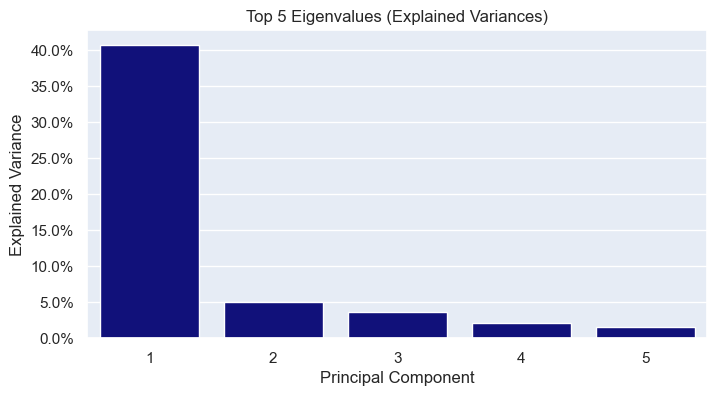

In [16]:
factor_returns, weights, pca = run_pca(stock_returns)
var_ratio = pca.explained_variance_ratio_
top_factors(var_ratio)

### 3b. Eigenvector Weights
First eigenvector has all positive weights — the market portfolio. Higher eigenvectors have positive and negative weights, grouping stocks by industry sector (Tables 1-2, Figures 4-6).

In [ ]:
graph_weights(weights, stock_returns.columns, 0)

In [ ]:
graph_weights(weights, stock_returns.columns, 1)

## 4. Backtest
Walk forward daily from day 252 onward. On each trade date:
- Re-estimate PCA on trailing 252 days (no look-ahead)
- Fit factor regression on trailing 60 days
- Compute s-scores, generate positions
- Record PNL after slippage

In [38]:
# results = run_backtest(stock_returns, debug_interval=252)
results = run_backtest(stock_returns, spy_returns)

## 5. Results
Performance diagnostics: Sharpe ratio, max drawdown, cost drag, position counts, and equity curve.

Period:          2019-01-04 00:00:00 to 2023-12-29 00:00:00
Total return:    2.45%
Annual return:   0.49%
Annual vol:      3.96%
Sharpe ratio:    0.12
Avg portfolio beta: 6.1937
Max drawdown:    -7.76%
Avg longs:       129
Avg shorts:      108
Gross PNL:       11.78
Total costs:     9.35
Cost drag:       79.40%
Number of Factors:3


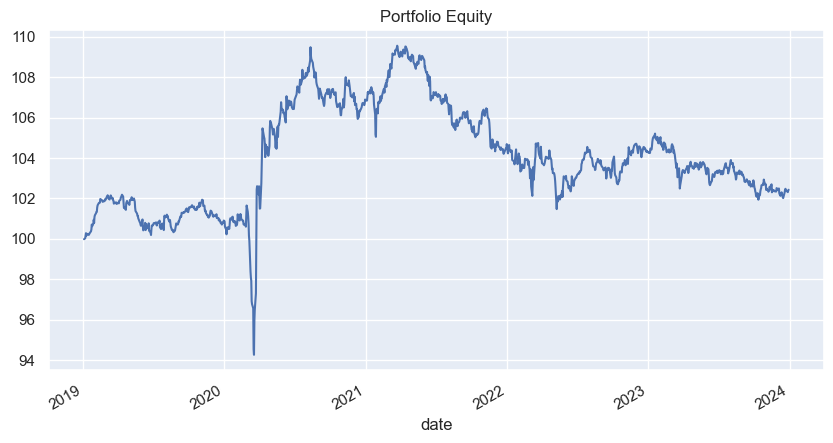

In [39]:
print_diagnostics(results)
results["equity"].plot(title="Portfolio Equity", figsize=(10, 5))
plt.show()

<Axes: title={'center': 'Portfolio Beta Over Time'}, xlabel='date'>

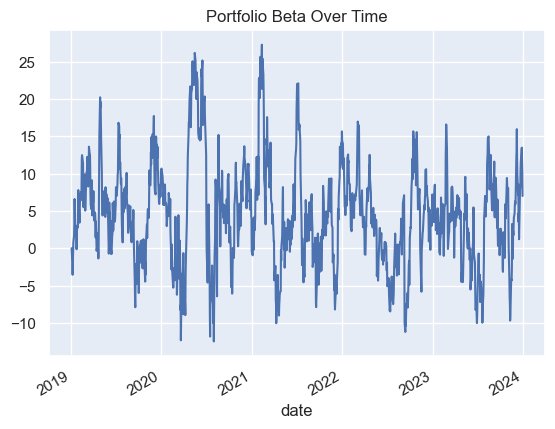

In [24]:
results["portfolio_beta"].plot(title="Portfolio Beta Over Time")